**Correction of solutions for the zenithal angle $\theta(t)$ of the spherical pendulum**

Analytical solution 1: $\theta_1(t)=\theta_0\left(1-\left(\frac{l}{g}u_0^2\right)^{1/4}\right)\cos\left(2\sqrt{\frac{g}{l}}\ t\right)+\theta_0\left(\frac{l}{g}u_0^2\right)^{1/4}$

Analytical solution 2: $\theta_2(t)=\frac{\theta_0-\theta_f}{2}\cos\left(2\sqrt{\frac{g}{l}}\ t\right)+\frac{\theta_0+\theta_f}{2}$


*Libraries to use:*

In [1]:
# General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# Machine Learning
# Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# XGBoost
import xgboost as xgb

Constants:

In [2]:
g=9.8 #m/s^2
l=0.182 #m

# Inicialization
u0, theta0, thetaf = 0, 0, 0
A, B, C, D = 0, 0, 0, 0

Functions (no ML):

In [3]:
# To determine the initial azimuthal speed from the dataset
def determine_u0(omega):
    peaks1, _ = find_peaks(omega, distance=15)
    peaks2, _ = find_peaks(-omega, distance=15)

    # Average of the firsts 3 maximums / 2 minimums
    aveg1 = (omega[peaks1[1]]+omega[peaks1[2]]+omega[peaks1[3]]) / 3
    aveg2 = (omega[peaks2[0]]+omega[peaks2[1]]) / 2
    #print(prom1)
    #print(prom2)

    # A vector is prepared and it's returned with both averages
    vec = []
    vec.append(aveg1)
    vec.append(aveg2)

    return vec

# To find the first valley
def valleys(t, theta):
    valleys, _ = find_peaks(-theta, distance=15)

    return valleys

# Function of the first analytical solution
def aSol1(df, omega):
    a=float(df['theta'].iloc[0])*(1-(l/g*float(df['ω'].iloc[0])**2)**(1/4))
    b=float(df['theta'].iloc[0])*(l/g*float(df['ω'].iloc[0])**2)**(1/4)
    sol=a*np.cos(omega*df['t'])+b

    sols=[]

    sols.append(a)
    sols.append(b)
    sols.append(sol)

    return sols

# Function of the second analytical solution
# Note: the variable "op" is used to indicate if the second extreme angle theta_f is a maximum or a minimum
def aSol2(df, omega, op):
    A, B = 0, 0
    if op==0:
        A=(float(df['theta'].iloc[0])-float(max(df['theta'])))/2
        B=(float(df['theta'].iloc[0])+float(max(df['theta'])))/2
    else:
        A=(float(df['theta'].iloc[0])-float(df['theta'].iloc[valleys(df['t'], df['theta'])[0]]))/2
        B=(float(df['theta'].iloc[0])+float(df['theta'].iloc[valleys(df['t'], df['theta'])[0]]))/2
    
    sols=[]

    sols.append(A)
    sols.append(B)

    sol=A*np.cos(omega*df['t'])+B

    sols.append(sol)

    return sols

# Function to graph the measurements and analytical solutions
def graph1(df):   
    
    plt.scatter(df['t'], df['theta'], label="Measurements", color="#63C4AF", s=10)
    
    plt.plot(df['t'], df['theta1'], label="Analytical solution 1", color="#00B4D8")
    plt.plot(df['t'], df['theta2'], label="Analytical solution 2", color="#FF6B6B")

    plt.title(r"$\theta$ vs t")
    plt.xlabel("t (s)")
    plt.ylabel(r"$\theta$ (rad)")
    
    max = 1.35*df[['theta', 'theta1', 'theta2']].max().max()
    plt.ylim(0, max)
    plt.grid()
    plt.legend(loc="best")
    plt.show()

def obtainR2(yreal, ypred):
    tss = ((yreal-yreal.mean())**2).sum()
    rss = ((yreal-ypred)**2).sum()

    r2 = 1 - (rss/tss)
    return r2

def r2_bargraph(df):
    # R2 for both models
    r2_theta1 = obtainR2(df['theta'].iloc[0:int(1/3 * len(df['theta']))], df['theta1'].iloc[0:int(1/3 * len(df['theta']))])
    r2_theta2 = obtainR2(df['theta'].iloc[0:int(1/3 * len(df['theta']))], df['theta2'].iloc[0:int(1/3 * len(df['theta']))])

    print(f"R^2 of theta 1: {r2_theta1}")
    print(f"R^2 of theta 2: {r2_theta2}")

    # Bar graph
    categories = [r"$\theta_1(t)$", r"$\theta_2(t)$"]
    values = [r2_theta1, r2_theta2]
    colors = ['#00B4D8', '#FF6B6B']

    plt.bar(categories, values, color=colors, edgecolor="black")
    
    plt.title(r"$R^2$ coefficient of the analytical solutions for $\theta$")
    plt.xlabel(r"Model of $\theta$")
    plt.ylabel(r"$R^2$ (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    v = []
    v.append(r2_theta1)
    v.append(r2_theta2)

    return v

def stdvS(r, n, p):
    return np.sqrt((r**2).sum()/(n-p))

def MAPE(y_real, y_pred):
    y_real, y_pred = np.array(y_real), np.array(y_pred)
    non_zero = y_real != 0
    y_real, y_pred = y_real[non_zero], y_pred[non_zero]
    return np.mean(np.abs((y_real-y_pred) / y_real)) * 100

def MdAPE(y_real, y_pred):
    y_real, y_pred = np.array(y_real), np.array(y_pred)
    non_zero = y_real != 0
    y_real, y_pred = y_real[non_zero], y_pred[non_zero]
    return np.median(np.abs((y_real-y_pred) / y_real)) * 100

def errortheta(df):
    mape1 = MAPE(df['theta'], df['theta1'])
    mape2 = MAPE(df['theta'], df['theta2'])
    
    mdape1 = MdAPE(df['theta'], df['theta1'])
    mdape2 = MdAPE(df['theta'], df['theta2'])
    
    # Errors (residues)    
    plt.figure()
    plt.scatter(df['t'], (df['theta']-df['theta1']) / stdvS((df['theta']-df['theta1']), len(df['theta']), 1), label=r"Standard residues $\theta_1(t)$", color="#00B4D8", s=10)
    plt.scatter(df['t'], (df['theta']-df['theta2']) / stdvS((df['theta']-df['theta2']), len(df['theta']), 1), label=r"Standard residues $\theta_2(t)$", color="#FF6B6B", s=10)
    plt.title(r"Standard residues of $\theta$ vs t")
    plt.xlabel("t (s)")
    plt.ylabel(r"Standard residues ($s$, standard deviations)")

    plt.grid()
    plt.legend(loc="best")
    plt.show()
    

    print(f"MAPE of the first model: {mape1}")
    print(f"MAPE of the second model: {mape2}")
        
    print(f"MdAPE of the first model: {mdape1}")
    print(f"MdAPE of the second model: {mdape2}")

    plt.figure()
    categories = ["MAPE1", "MAPE2", "MdAPE1", "MdAPE2"]
    values = [mape1, mape2, mdape1, mdape2]
    colors = ["#00B4D8", "#FF6B6B", "#00B4D8", "#FF6B6B"]
    plt.bar(categories, values, color=colors, edgecolor="black")

    plt.title(r"Porcentual error metrics of $\theta_1(t)$ and $\theta_2(t)$")
    plt.xlabel("Metrics")
    plt.ylabel("Result of the metrics (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

    v = []
    v.append(mape1)
    v.append(mape2)
    v.append(mdape1)
    v.append(mdape2)

    return v

# Performance of solutions

## Experiment 1

Initial azimuthal angular speed: 10.295326 rad/s


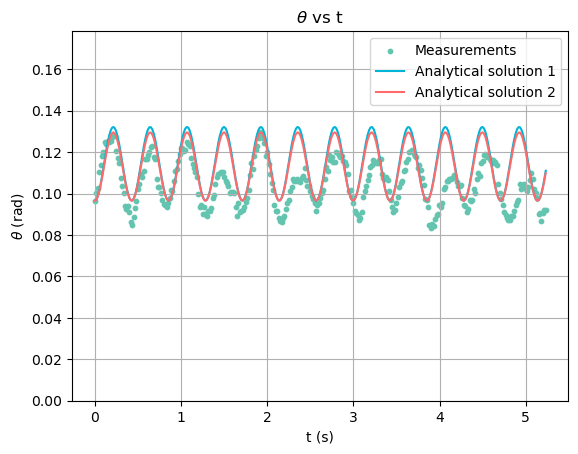

R^2 of theta 1: 0.19147008932522058
R^2 of theta 2: 0.3552041975503992


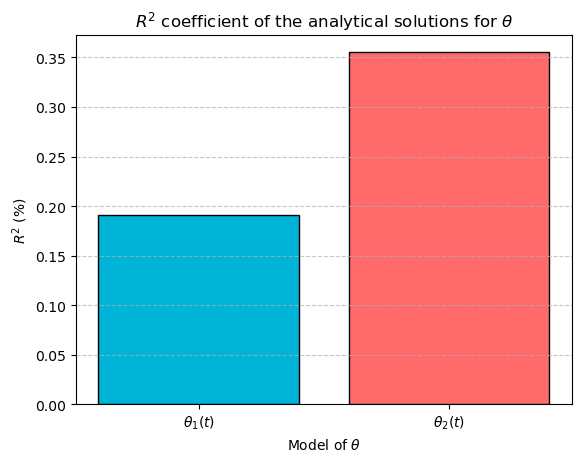

In [ ]:
# Replace this with the actual path!
file_path1 = r"\Classical mechanics and machine learning proyect\S2_R1_1.xlsx"

df_1 = pd.read_excel(file_path1)

omega=2*(g/l)**(1/2)
i=0
#======================================Calculation of u0 and insertion to the database df======================================
df_1.loc[0, 'ω']=determine_u0(df_1['ω'])[i]
print(f"Initial azimuthal angular speed: {float(df_1.loc[0, 'ω'])} rad/s")
# print(f"Sqrt(g/l * sec theta0)={np.sqrt(g/l*1/np.cos(float(df.loc[0, 'theta'])))} rad/s")

#==========================================================Solución analítica 1==========================================================
vec1=aSol1(df_1, omega)
A=vec1[0]
B=vec1[1]
df_1['theta1']=vec1[2]


#==========================================================Solución analítica 2==========================================================
vec2=aSol2(df_1, omega, i)
C=vec2[0]
D=vec2[1]
df_1['theta2']=vec2[2]

graph1(df_1)

r2_1_1 = r2_bargraph(df_1)

Error of the solution

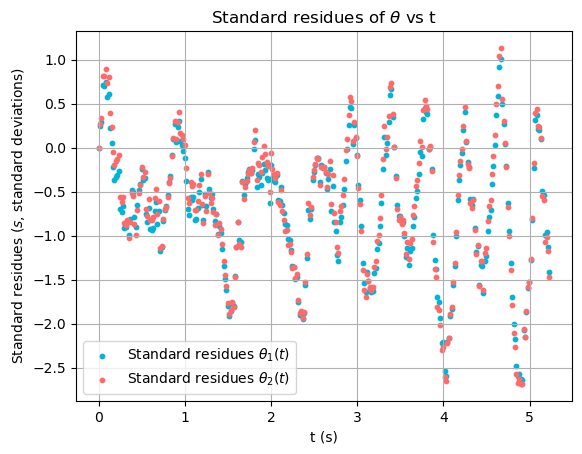

MAPE of the first model: 10.422068917932927
MAPE of the second model: 9.426376107678745
MdAPE of the first model: 8.371280755221155
MdAPE of the second model: 7.551624528938859


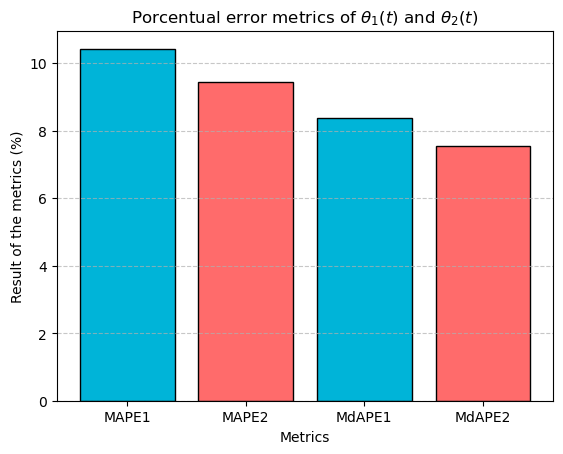

In [7]:
metrics_1_1 = errortheta(df_1)

## Experiment 2

Initial azimuthal angular speed: 16.846026666666663 rad/s


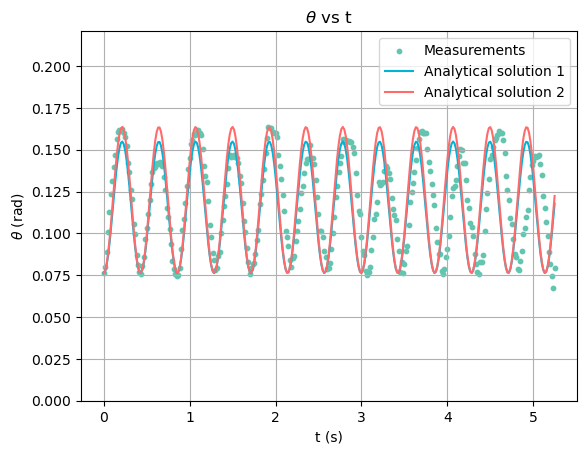

R^2 of theta 1: 0.8715003221974689
R^2 of theta 2: 0.8764409503023792


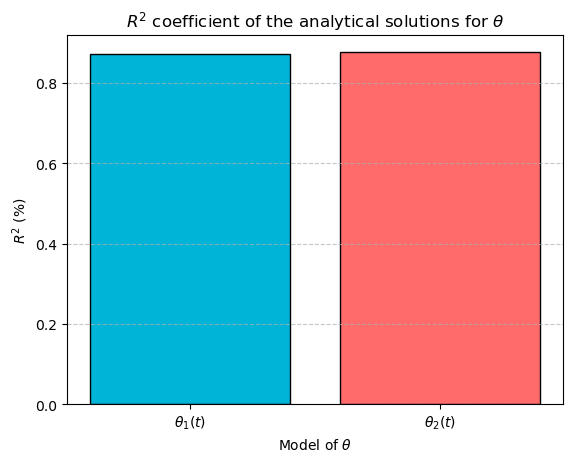

In [ ]:
# Replace this with the actual path!
file_path2 = r"\Classical mechanics and machine learning proyect\S2_R1_2.xlsx"
df_2 = pd.read_excel(file_path2)

i=0
#======================================Calculation of u0 and insertion to the database df======================================
df_2.loc[0, 'ω']=determine_u0(df_2['ω'])[i]
print(f"Initial azimuthal angular speed: {float(df_2.loc[0, 'ω'])} rad/s")
# print(f"Sqrt(g/l * sec theta0)={np.sqrt(g/l*1/np.cos(float(df.loc[0, 'theta'])))} rad/s")

#==========================================================Solución analítica 1==========================================================
vec1=aSol1(df_2, omega)
A=vec1[0]
B=vec1[1]
df_2['theta1']=vec1[2]


#==========================================================Solución analítica 2==========================================================
vec2=aSol2(df_2, omega, i)
C=vec2[0]
D=vec2[1]
df_2['theta2']=vec2[2]

graph1(df_2)
r2_1_2 = r2_bargraph(df_2)

Error of the solution

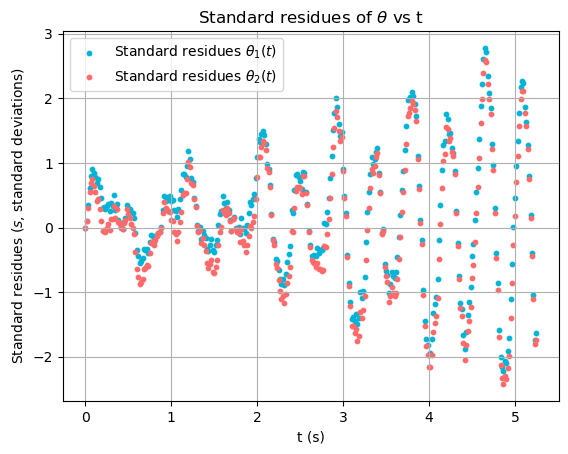

MAPE of the first model: 15.828510971429703
MAPE of the second model: 16.703839460569554
MdAPE of the first model: 11.768894523413909
MdAPE of the second model: 12.665752534303623


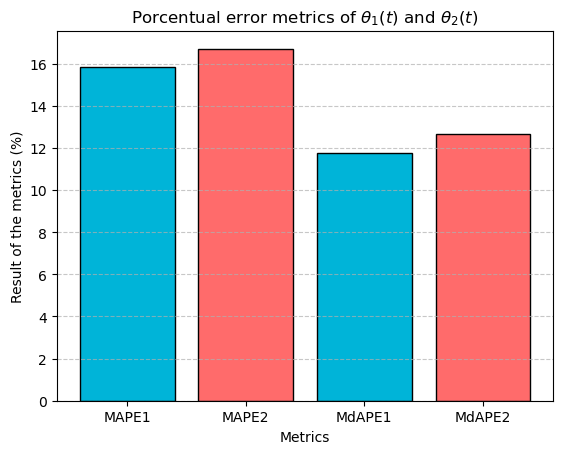

In [9]:
metrics_1_2 = errortheta(df_2)

## Experiment 3

Initial azimuthal angular speed: 16.474953333333332 rad/s


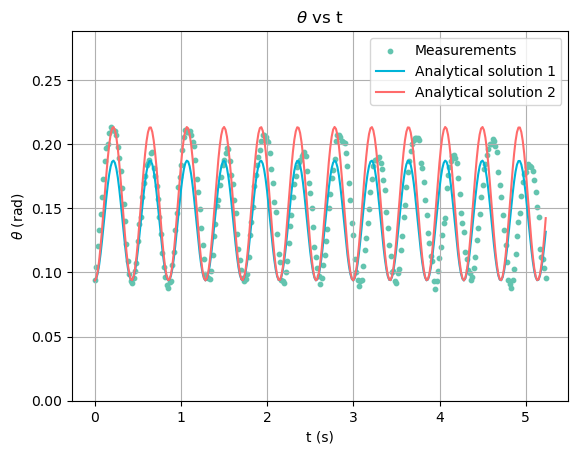

R^2 of theta 1: 0.7720466903324061
R^2 of theta 2: 0.8674788888701682


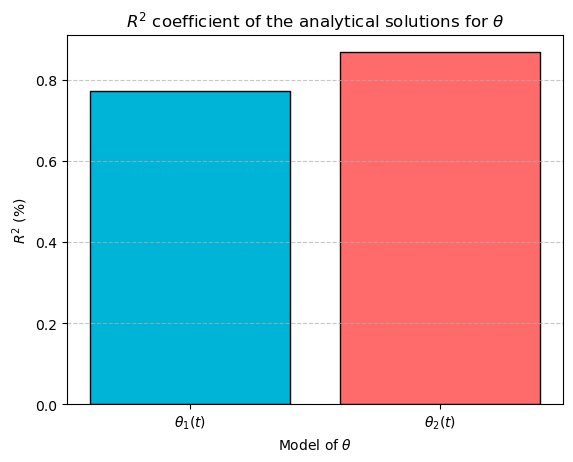

In [ ]:
# Replace this with the actual path!
file_path3 = r"\Classical mechanics and machine learning proyect\S2_R1_3.xlsx"
df_3 = pd.read_excel(file_path3)

i=0
#======================================Calculation of u0 and insertion to the database df======================================
df_3.loc[0, 'ω']=determine_u0(df_3['ω'])[i]
print(f"Initial azimuthal angular speed: {float(df_3.loc[0, 'ω'])} rad/s")
# print(f"Sqrt(g/l * sec theta0)={np.sqrt(g/l*1/np.cos(float(df.loc[0, 'theta'])))} rad/s")

#==========================================================Solución analítica 1==========================================================
vec1=aSol1(df_3, omega)
A=vec1[0]
B=vec1[1]
df_3['theta1']=vec1[2]


#==========================================================Solución analítica 2==========================================================
vec2=aSol2(df_3, omega, i)
C=vec2[0]
D=vec2[1]
df_3['theta2']=vec2[2]

graph1(df_3)

r2_1_3 = r2_bargraph(df_3)

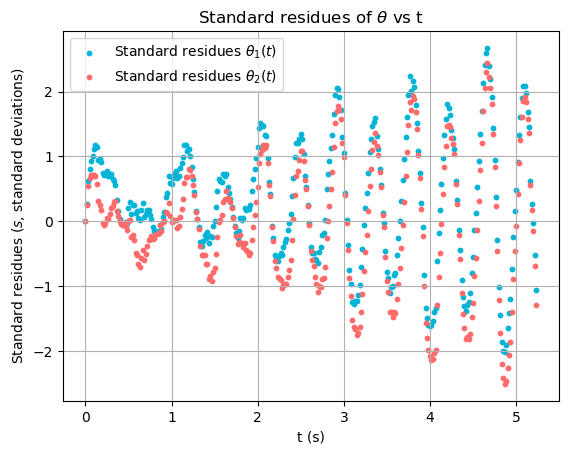

MAPE of the first model: 18.00710217034764
MAPE of the second model: 19.843238780397073
MdAPE of the first model: 14.766396342867417
MdAPE of the second model: 15.680497800155221


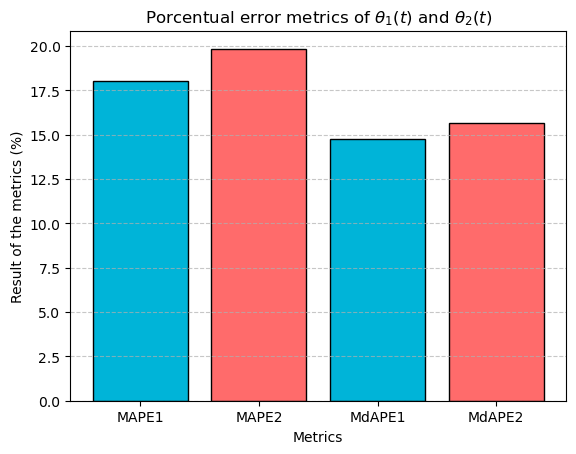

In [11]:
metrics_1_3 = errortheta(df_3)

# Correction of solutions

## Logic of correction

Since the residues have a clear pattern, we can use machine learning for predicting those residues, add them to the prediction of the analytical solution and obtain a better prediction. This way, we create hybrid models. Thus:

If residues $R$ are:
\begin{equation}
    R=\theta_{real}-\theta_i(t),\quad i=1,2
\end{equation}
Then:
\begin{equation}
    \theta_{real}=\theta_i(t)+R\rightarrow\theta_{hybrid}(t)=\theta_i(t)+R_{ML}
\end{equation}

ML functions:

In [36]:
def residuals1(df):
    resids=df['theta']-df['theta1']
    return resids

def residuals2(df):
    resids=df['theta']-df['theta2']
    return resids

# Function to build the hybrid model
def thetaCorrected(df, resids1, resids2):
    theta1ML = df['theta1'] + df[resids1]
    theta2ML = df['theta2'] + df[resids2]

    thetai=[]
    thetai.append(theta1ML)
    thetai.append(theta2ML)

    return thetai

# Random Forest (RF)
def randomForest(df, resids):
    # Features and target column
    features = df[['t', 'phi', 'ω']]
    target = df[resids]

    # Distribution of data for training and evaluation
    features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

    # Training
    rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=3, max_features='sqrt', bootstrap=True, random_state=42, n_jobs=-1)

    rf.fit(features_train, target_train)

    # Forecast
    resids_pred = rf.predict(features_test)

    mape = MAPE(target_test, resids_pred)
    mdape = MdAPE(target_test, resids_pred)

    resi = rf.predict(features)

    v=[]
    v.append(mape)
    v.append(mdape)
    v.append(resi)
    
    return v

def graphRF1(df):
    r2_RF = obtainR2(df['theta'], df['theta1RF'])
    print(f"R2: {r2_RF}")

    plt.scatter(df['t'], df['theta'], label="Measurements", color="#748884", s=12)
    plt.plot(df['t'], df['theta1'], label=r"$\theta_1(t)$", color="#00B4D8")
    plt.plot(df['t'], df['theta1RF'], label=r"$\theta_1(t)+R_{RF}$", color="#503885FF")
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")

    plt.title(r"$\theta$ vs t")
    plt.xlabel(r"$t$ (s)")
    plt.ylabel(r"$\theta$ (rad)")
    plt.ylim(0, 1.38*df[['theta', 'theta1', 'theta1RF']].max().max())

    plt.grid()
    plt.legend(loc="best")
    plt.show()

    return r2_RF

def graphRF2(df):
    r2_RF = obtainR2(df['theta'], df['theta2RF'])
    print(f"R2: {r2_RF}")

    plt.scatter(df['t'], df['theta'], label="Measurements", color="#748884", s=12)
    plt.plot(df['t'], df['theta2'], label=r"$\theta_2(t)$", color="#FF6B6B")
    plt.plot(df['t'], df['theta2RF'], label=r"$\theta_2(t)+R_{RF}$", color="#C4D82B")
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")

    plt.title(r"$\theta$ vs t")
    plt.xlabel(r"$t$ (s)")
    plt.ylabel(r"$\theta$ (rad)")
    plt.ylim(0, 1.38*df[['theta', 'theta2', 'theta2RF']].max().max())

    plt.grid()
    plt.legend(loc="best")
    plt.show()

    return r2_RF

def randomForestTotal(df):
    v1=randomForest(df, "resids1")
    v2=randomForest(df, "resids2")

    # Residues forecasted by ML model
    df['resids1RF'] = v1[2]
    df['resids2RF'] = v2[2]

    # Analytical models with corrections
    ml = thetaCorrected(df, 'resids1RF', 'resids2RF')

    df['theta1RF'] = ml[0]
    df['theta2RF'] = ml[1]

    r2_1 = graphRF1(df)
    r2_2 = graphRF2(df)

    v = []
    v.append(r2_1)
    v.append(r2_2)

    return v

def residsRF(df):
    plt.figure()
    plt.scatter(df['t'], (df['theta']-df['theta1RF']) / stdvS((df['theta']-df['theta1RF']), len(df['theta']), 3), label=r"Standard residues of $\theta_1(t)+R_{RF}$", color="#503885FF", s=10)
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")
    plt.xlabel(r"$t$ (s)")
    plt.ylabel(r"Standard residues ($s$, standard deviations)")
    plt.title(r"Standard residues of $\theta_1(t)+R_{RF}$ vs $t$")
    plt.legend(loc="best")
    plt.grid()
    
    plt.figure()
    plt.scatter(df['t'], (df['theta']-df['theta2RF']) / stdvS((df['theta']-df['theta2RF']), len(df['theta']), 3), label=r"Standard residues of $\theta_2(t)+R_{RF}$", color="#C4D82B", s=10)
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")
    plt.xlabel(r"$t$ (s)")
    plt.ylabel(r"Standard residues ($s$, standard deviations)")
    plt.title(r"Standard residues of $\theta_2(t)+R_{RF}$ vs $t$")
    plt.legend(loc="best")
    plt.grid()
    
    plt.show()

def r2_bargraph_RF(df):
    # R2 for both models
    r2_theta1 = obtainR2(df['theta'], df['theta1RF'])
    r2_theta2 = obtainR2(df['theta'], df['theta2RF'])

    print(f"R^2 of theta 1: {r2_theta1}")
    print(f"R^2 of theta 2: {r2_theta2}")

    # Bar graph
    categories = [r"$\theta_1(t)+R_{RF}$", r"$\theta_2(t)+R_{RF}$"]
    values = [r2_theta1, r2_theta2]
    colors = ['#503885FF', '#C4D82B']

    plt.bar(categories, values, color=colors, edgecolor="black")
    
    plt.title(r"$R^2$ coefficient of the hybrid solutions for $\theta_{i}(t)+R_{RF}$")
    plt.xlabel(r"Model of $\theta$")
    plt.ylabel(r"$R^2$ (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def errortheta_RF(df):
    mape1 = MAPE(df['theta'], df['theta1RF'])
    mape2 = MAPE(df['theta'], df['theta2RF'])
    
    mdape1 = MdAPE(df['theta'], df['theta1RF'])
    mdape2 = MdAPE(df['theta'], df['theta2RF'])    

    print(f"MAPE of the first model: {mape1}")
    print(f"MAPE of the second model: {mape2}")
        
    print(f"MdAPE of the first model: {mdape1}")
    print(f"MdAPE of the second model: {mdape2}")

    plt.figure()
    categories = ["MAPE1", "MAPE2", "MdAPE1", "MdAPE2"]
    values = [mape1, mape2, mdape1, mdape2]
    colors = ["#503885FF", "#C4D82B", "#503885FF", "#C4D82B"]
    plt.bar(categories, values, color=colors, edgecolor="black")

    plt.title(r"Porcentual error metrics of $\theta_i(t)+R_{RF}$")
    plt.xlabel("Metrics")
    plt.ylabel("Result of the metrics (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

    v = []
    v.append(mape1)
    v.append(mape2)
    v.append(mdape1)
    v.append(mdape2)

    return v

# XG Boost
def xgBoost(df, resids):
    # Features and target column
    features = df[['t', 'phi', 'ω']]
    target = df[resids]

    # Data distribution for training and evaluation
    features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

    # Training
    dtrain = xgb.DMatrix(features_train, label=target_train)
    dtest = xgb.DMatrix(features_test, label=target_test)

    params = {'objective': 'reg:squarederror', 'max_depth': 3, 'eta': 0.1, 'subsample': 0.8, 'seed': 42}

    num_rounds = 100
    xg = xgb.train(params, dtrain, num_rounds)

    # Forecast
    resids_pred = xg.predict(dtest)

    resi = xg.predict(xgb.DMatrix(features, target))
    
    return resi

def graphXGB1(df):
    r2_XGB = obtainR2(df['theta'], df['theta1XGB'])
    print(f"R2: {r2_XGB}")

    plt.scatter(df['t'], df['theta'], label="Measuments", color="#748884", s=12)
    plt.plot(df['t'], df['theta1'], label=r"$\theta_1(t)$", color="#00B4D8")
    plt.plot(df['t'], df['theta1XGB'], label=r"$\theta_1(t)+R_{XGB}$", color="#503885FF")
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")

    plt.title(r"$\theta$ vs t")
    plt.xlabel("t (s)")
    plt.ylabel(r"$\theta$ (rad)")
    plt.ylim(0, 1.38*df[['theta', 'theta1', 'theta1XGB']].max().max())

    plt.grid()
    plt.legend(loc="best")
    plt.show()

    return r2_XGB

def graphXGB2(df):
    r2_XGB = obtainR2(df['theta'], df['theta2XGB'])
    print(f"R2: {r2_XGB}")

    plt.scatter(df['t'], df['theta'], label="Measurements", color="#748884", s=12)
    plt.plot(df['t'], df['theta2'], label=r"$\theta_2(t)$", color="#FF6B6B")
    plt.plot(df['t'], df['theta2XGB'], label=r"$\theta_2(t)+R_{XGB}$", color="#C4D82B")
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")

    plt.title(r"$\theta$ vs t")
    plt.xlabel("t (s)")
    plt.ylabel(r"$\theta$ (rad)")
    plt.ylim(0, 1.38*df[['theta', 'theta2', 'theta2XGB']].max().max())

    plt.grid()
    plt.legend(loc="best")
    plt.show()

    return r2_XGB

def XGBoostTotal(df):
    # Residues predicted by ML model
    #df['resids1XGB'] = v1[2]
    df['resids1XGB'] = xgBoost(df, "resids1")
    #df['resids2XGB'] = v2[2]
    df['resids2XGB'] = xgBoost(df, "resids2")

    # Theoretical models with the corrections
    ml = thetaCorrected(df, 'resids1XGB', 'resids2XGB')

    df['theta1XGB'] = ml[0]
    df['theta2XGB'] = ml[1]

    # Evaluation metrics
    mape1 = MAPE(df['theta'], df['theta1XGB'])
    mape2 = MAPE(df['theta'], df['theta2XGB'])
    mdape1= MdAPE(df['theta'], df['theta1XGB'])
    mdape2 = MdAPE(df['theta'], df['theta2XGB'])

    r2_1 = graphXGB1(df)
    r2_2 = graphXGB2(df)

    v = []
    v.append(r2_1)
    v.append(r2_2)
    v.append(mape1)
    v.append(mape2)
    v.append(mdape1)
    v.append(mdape2)

    return v

def residsXGB(df):
    plt.figure()
    plt.scatter(df['t'], (df['theta']-df['theta1XGB']) / stdvS((df['theta']-df['theta1XGB']), len(df['theta']), 3), label=r"Standard residues $\theta_1(t)+R_{XGB}$", color="#503885FF", s=10)
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")
    plt.xlabel("t (s)")
    plt.ylabel(r"Standard residues ($s$, standard deviations)")
    plt.title(r"Standard residues of $\theta_1(t)+R_{XGB}$ vs $t$")
    plt.legend(loc="best")
    plt.grid()
    
    plt.figure()
    plt.scatter(df['t'], (df['theta']-df['theta2XGB']) / stdvS((df['theta']-df['theta2XGB']), len(df['theta']), 3), label=r"Standard residues $\theta_2(t)+R_{XGB}$", color="#C4D82B", s=10)
    plt.axvline(x=df['t'].max()*0.80, color="black", linestyle="--", linewidth=0.95, label=r"80% of the data")
    plt.xlabel("t (s)")
    plt.ylabel(r"Standard residues ($s$, standard deviations)")
    plt.title(r"Standard residues of $\theta_2(t)+R_{XGB}$ vs $t$")
    plt.legend(loc="best")
    plt.grid()
    
    plt.show()

def r2_bargraph_XGB(df):
    # R2 for both models
    r2_theta1 = obtainR2(df['theta'], df['theta1XGB'])
    r2_theta2 = obtainR2(df['theta'], df['theta2XGB'])

    print(f"R^2 of theta 1: {r2_theta1}")
    print(f"R^2 of theta 2: {r2_theta2}")

    # Bar graph
    categories = [r"$\theta_1(t)+R_{XGB}$", r"$\theta_2(t)+R_{XGB}$"]
    values = [r2_theta1, r2_theta2]
    colors = ['#503885FF', '#C4D82B']

    plt.bar(categories, values, color=colors, edgecolor="black")
    
    plt.title(r"$R^2$ coefficient of the hybrid solutions for $\theta_{i}(t)+R_{XGB}$")
    plt.xlabel(r"Model of $\theta$")
    plt.ylabel(r"$R^2$ (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def errortheta_XGB(df):
    mape1 = MAPE(df['theta'], df['theta1XGB'])
    mape2 = MAPE(df['theta'], df['theta2XGB'])
    
    mdape1 = MdAPE(df['theta'], df['theta1XGB'])
    mdape2 = MdAPE(df['theta'], df['theta2XGB'])    

    print(f"MAPE of the first model: {mape1}")
    print(f"MAPE of the second model: {mape2}")
        
    print(f"MdAPE of the first model: {mdape1}")
    print(f"MdAPE of the second model: {mdape2}")

    plt.figure()
    categories = ["MAPE1", "MAPE2", "MdAPE1", "MdAPE2"]
    values = [mape1, mape2, mdape1, mdape2]
    colors = ["#503885FF", "#C4D82B", "#503885FF", "#C4D82B"]
    plt.bar(categories, values, color=colors, edgecolor="black")

    plt.title(r"Porcentual error metrics of $\theta_i(t)+R_{XGB}$")
    plt.xlabel("Metrics")
    plt.ylabel("Result of the metrics (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

## Corrections by random forest (RF)

### Corrections on experiment 1

R2: 0.7522094657744509


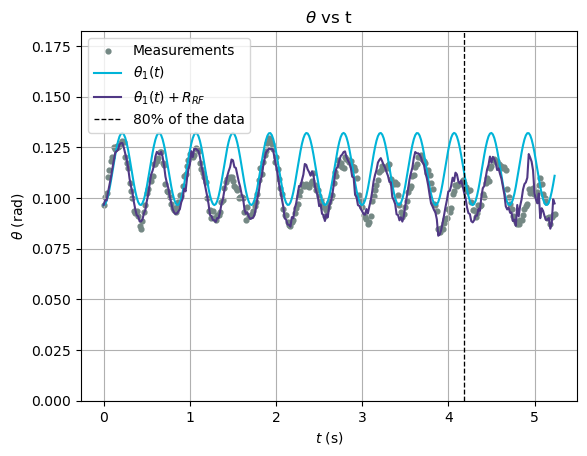

R2: 0.7839958838130524


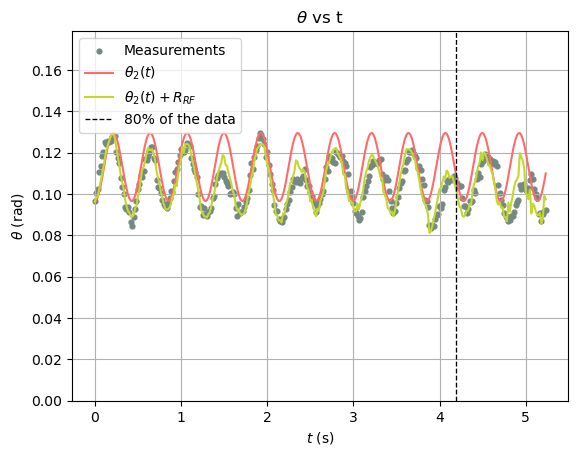

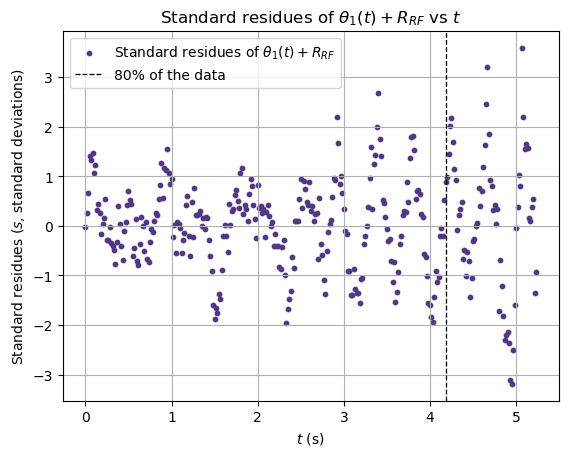

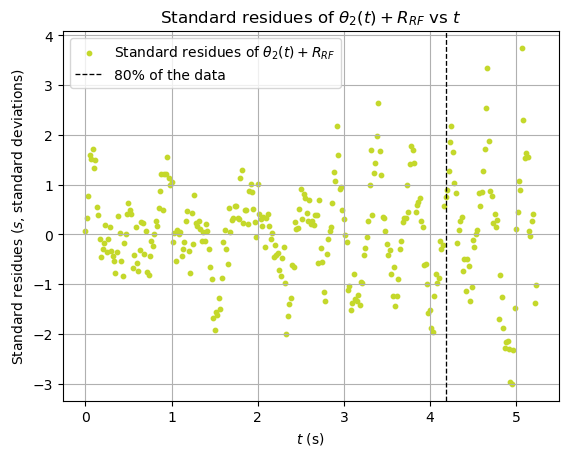

In [37]:
# Calculation of residues
df_1['resids1']=residuals1(df_1)
df_1['resids2']=residuals2(df_1)

v_RF_1 = randomForestTotal(df_1)
r2_2_1 = []
r2_2_1.append(v_RF_1[0])
r2_2_1.append(v_RF_1[1])
residsRF(df_1)

R^2 of theta 1: 0.7522094657744509
R^2 of theta 2: 0.7839958838130524


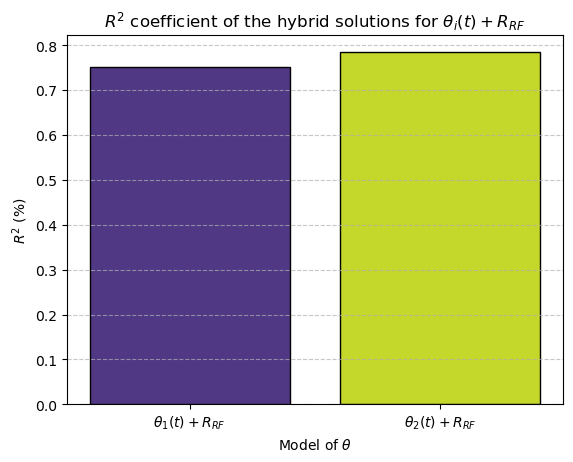

MAPE of the first model: 4.00878626156547
MAPE of the second model: 3.7383723259151505
MdAPE of the first model: 2.928997089947002
MdAPE of the second model: 2.6908250300640155


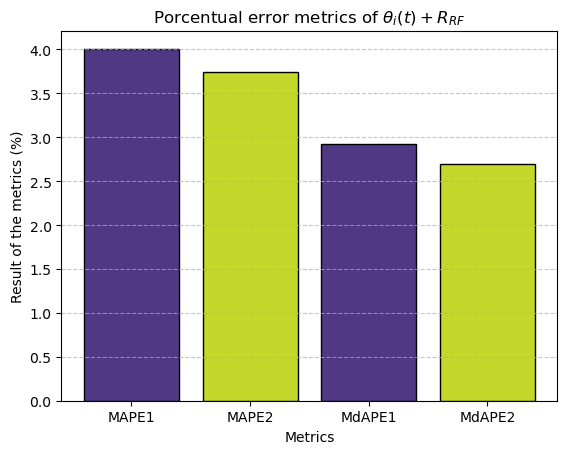

In [17]:
r2_bargraph_RF(df_1)
metrics_RF_1 = errortheta_RF(df_1)
metrics_2_1 = []
metrics_2_1.append(metrics_RF_1[0])
metrics_2_1.append(metrics_RF_1[1])
metrics_2_1.append(metrics_RF_1[2])
metrics_2_1.append(metrics_RF_1[3])

### Corrections on experiment 2

R2: 0.7886906934613049


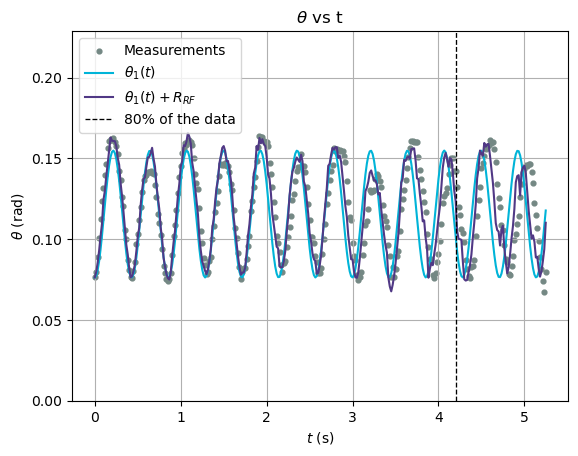

R2: 0.7518252090013059


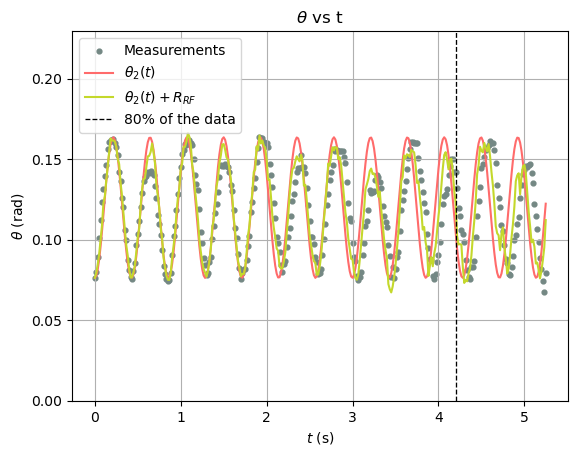

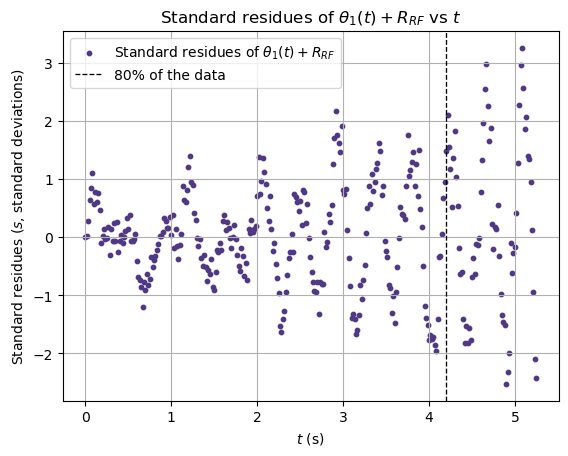

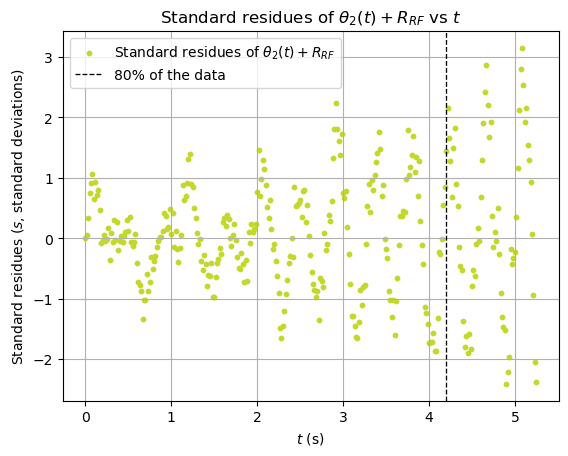

In [38]:
# Calculation of residues
df_2['resids1']=residuals1(df_2)
df_2['resids2']=residuals2(df_2)

v_RF_2 = randomForestTotal(df_2)
r2_2_2 = []
r2_2_2.append(v_RF_2[0])
r2_2_2.append(v_RF_2[1])
residsRF(df_2)

R^2 of theta 1: 0.7886906934613049
R^2 of theta 2: 0.7518252090013059


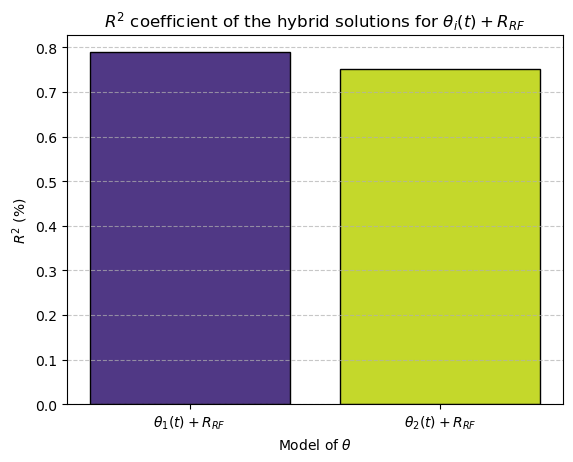

MAPE of the first model: 8.41473142481221
MAPE of the second model: 9.121137130716019
MdAPE of the first model: 6.315636692439064
MdAPE of the second model: 6.951794373348277


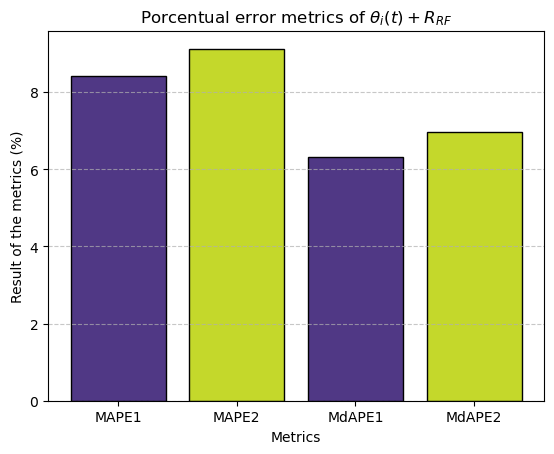

In [19]:
r2_bargraph_RF(df_2)
metrics_RF_2 = errortheta_RF(df_2)
metrics_2_2 = []
metrics_2_2.append(metrics_RF_2[0])
metrics_2_2.append(metrics_RF_2[1])
metrics_2_2.append(metrics_RF_2[2])
metrics_2_2.append(metrics_RF_2[3])

### Corrections on experiment 3

R2: 0.8120937068076324


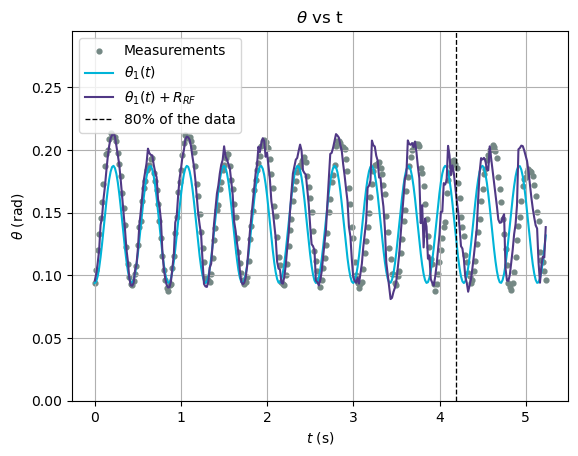

R2: 0.7285934467226962


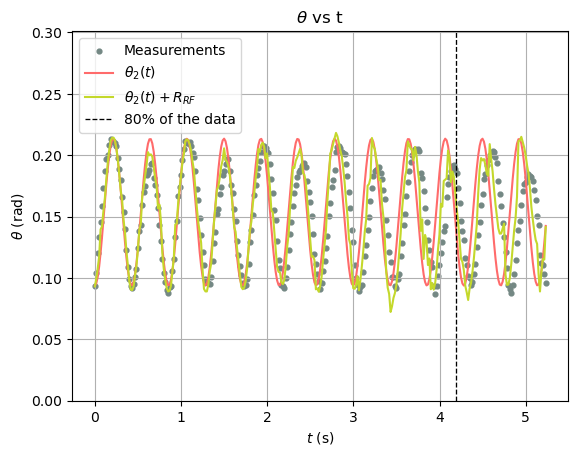

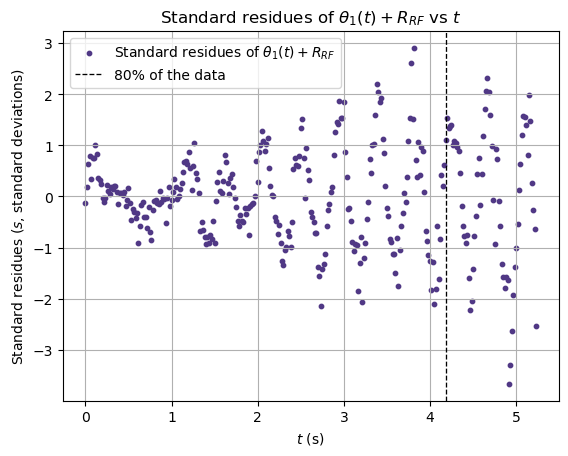

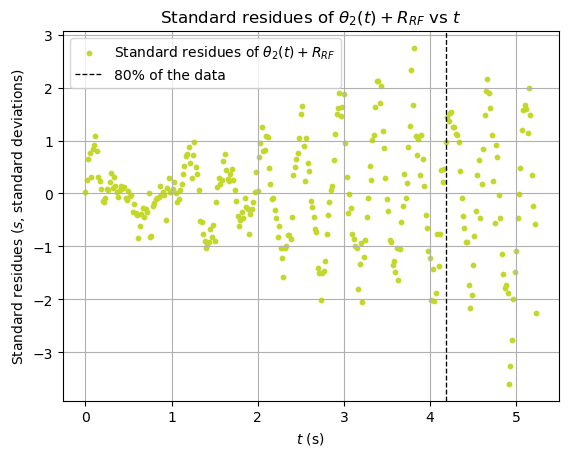

In [39]:
# Calculation of residues
df_3['resids1']=residuals1(df_3)
df_3['resids2']=residuals2(df_3)

v_RF_3 = randomForestTotal(df_3)
r2_2_3 = []
r2_2_3.append(v_RF_3[0])
r2_2_3.append(v_RF_3[1])

residsRF(df_3)

R^2 of theta 1: 0.8120937068076324
R^2 of theta 2: 0.7285934467226962


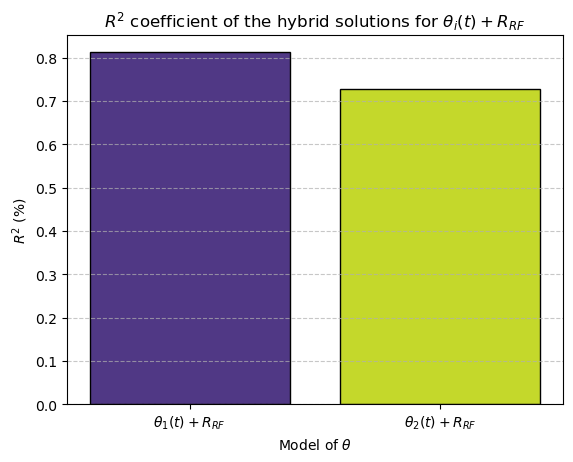

MAPE of the first model: 8.92336008017292
MAPE of the second model: 10.674154307683406
MdAPE of the first model: 7.618497786907365
MdAPE of the second model: 8.716580077377198


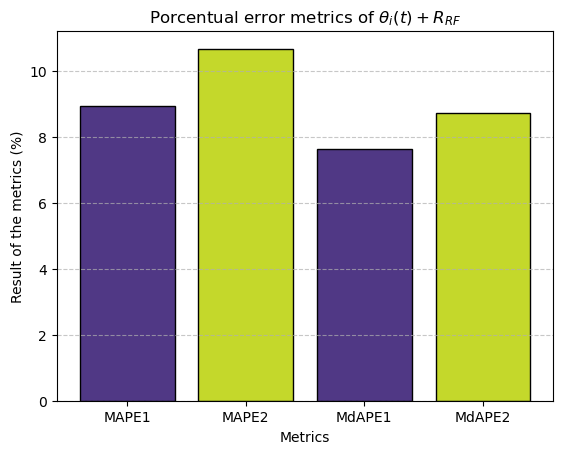

In [21]:
r2_bargraph_RF(df_3)
metrics_RF_3 = errortheta_RF(df_3)
metrics_2_3 = []
metrics_2_3.append(metrics_RF_3[0])
metrics_2_3.append(metrics_RF_3[1])
metrics_2_3.append(metrics_RF_3[2])
metrics_2_3.append(metrics_RF_3[3])

## Corrections by XGBoost (XGB)

### Corrections on experiment 1

R2: 0.9169308633480379


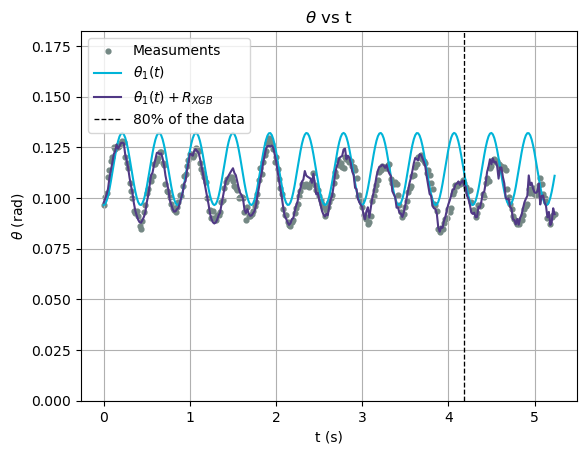

R2: 0.92288028420304


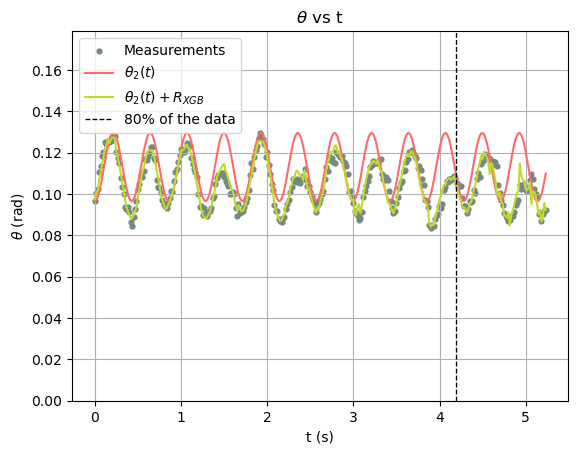

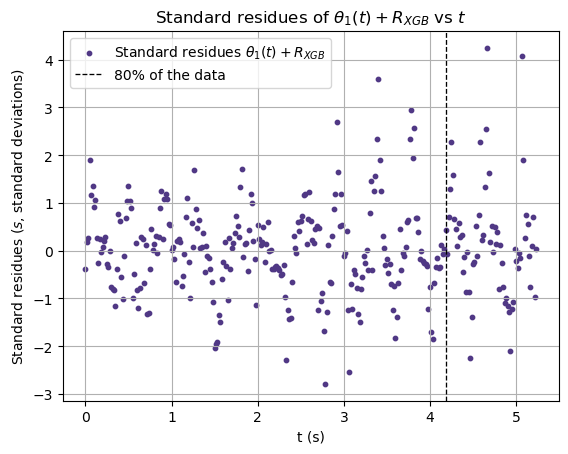

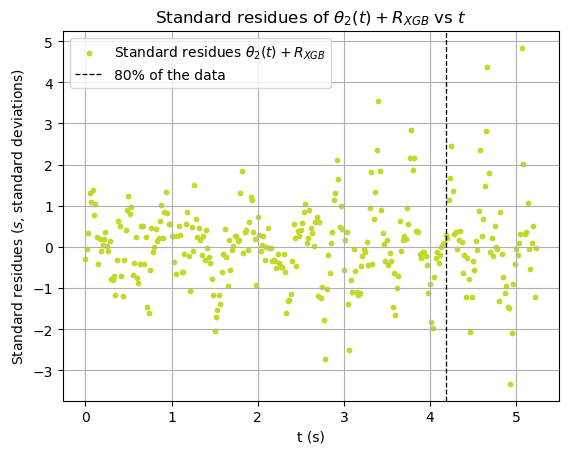

In [22]:
v_XGB_1 = XGBoostTotal(df_1)
r2_3_1 = []
r2_3_1.append(v_XGB_1[0])
r2_3_1.append(v_XGB_1[1])
metrics_3_1 = []
metrics_3_1.append(v_XGB_1[2])
metrics_3_1.append(v_XGB_1[3])
metrics_3_1.append(v_XGB_1[4])
metrics_3_1.append(v_XGB_1[5])

residsXGB(df_1)

R^2 of theta 1: 0.9169308633480379
R^2 of theta 2: 0.92288028420304


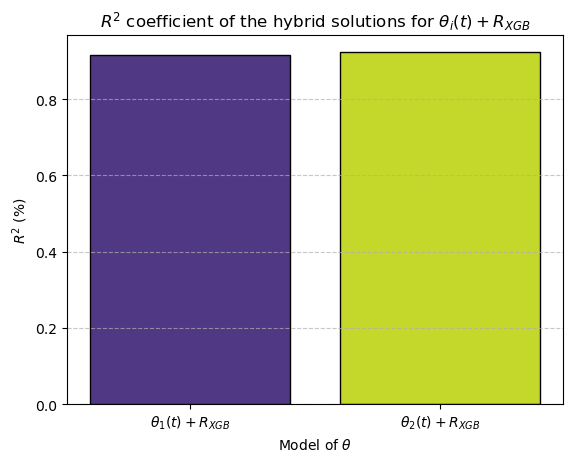

MAPE of the first model: 2.2070351649657294
MAPE of the second model: 2.077037513985957
MdAPE of the first model: 1.569203809180925
MdAPE of the second model: 1.4303859544168505


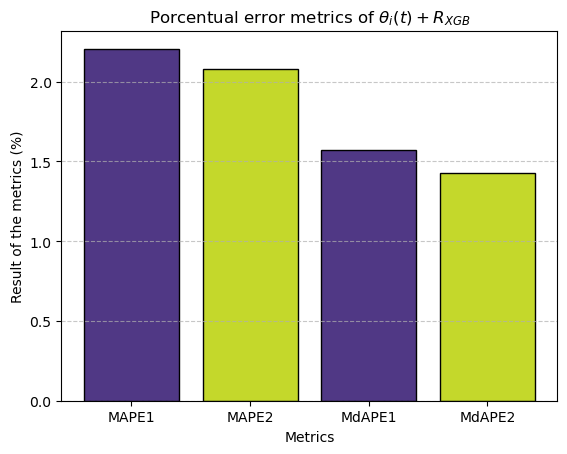

In [23]:
r2_bargraph_XGB(df_1)
errortheta_XGB(df_1)

### Corrections on experiment 2

R2: 0.9409456586559525


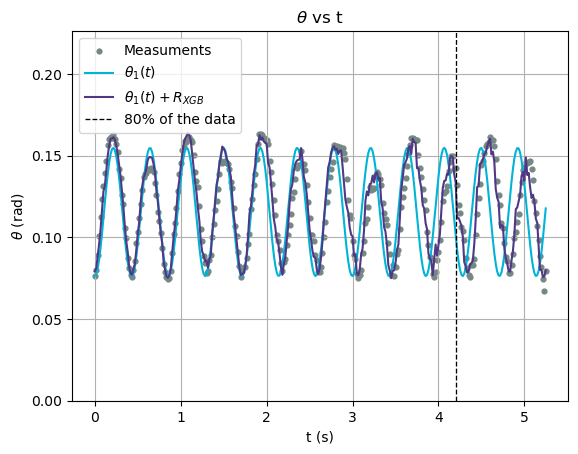

R2: 0.9235569958664018


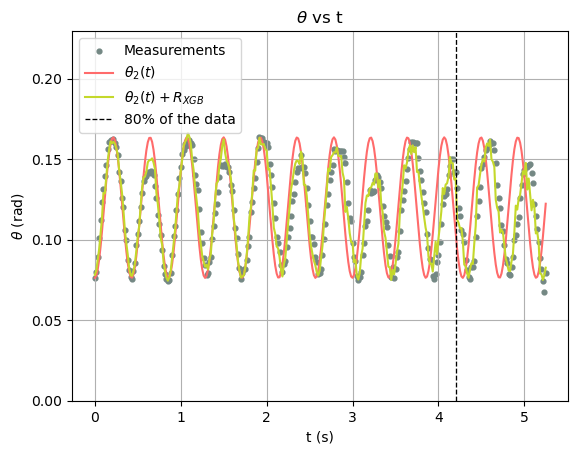

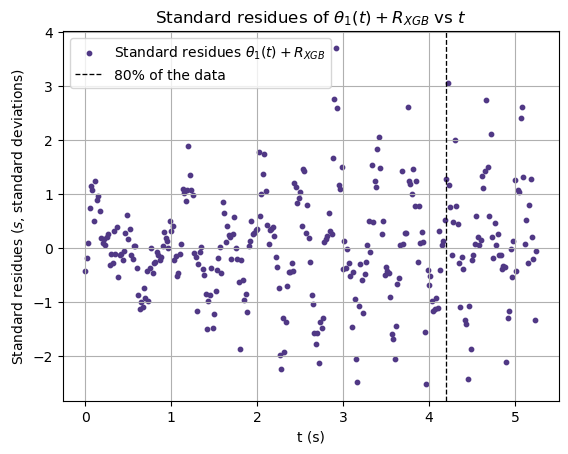

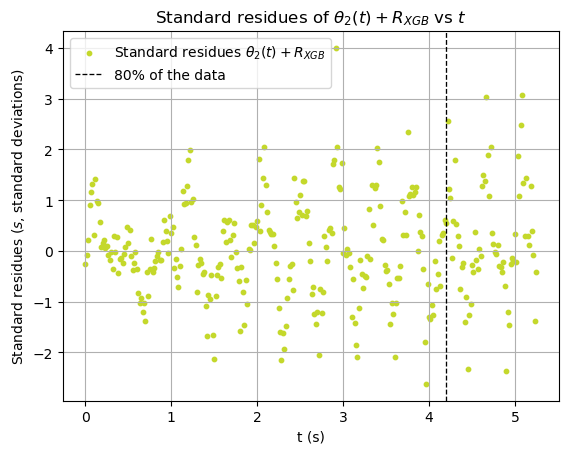

In [24]:
v_XGB_2 = XGBoostTotal(df_2)
r2_3_2 = []
r2_3_2.append(v_XGB_2[0])
r2_3_2.append(v_XGB_2[1])
metrics_3_2 = []
metrics_3_2.append(v_XGB_2[2])
metrics_3_2.append(v_XGB_2[3])
metrics_3_2.append(v_XGB_2[4])
metrics_3_2.append(v_XGB_2[5])

residsXGB(df_2)

R^2 of theta 1: 0.9409456586559525
R^2 of theta 2: 0.9235569958664018


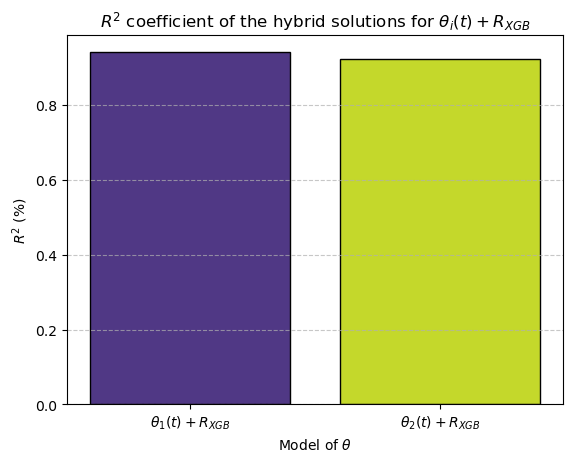

MAPE of the first model: 4.2603056686167555
MAPE of the second model: 4.9046486870105666
MdAPE of the first model: 3.085415985486298
MdAPE of the second model: 3.5662636628508575


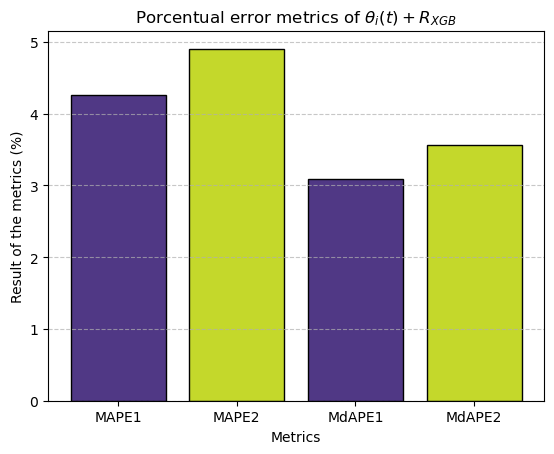

In [25]:
r2_bargraph_XGB(df_2)
errortheta_XGB(df_2)

### Corrections on experiment 3

R2: 0.9208924448289594


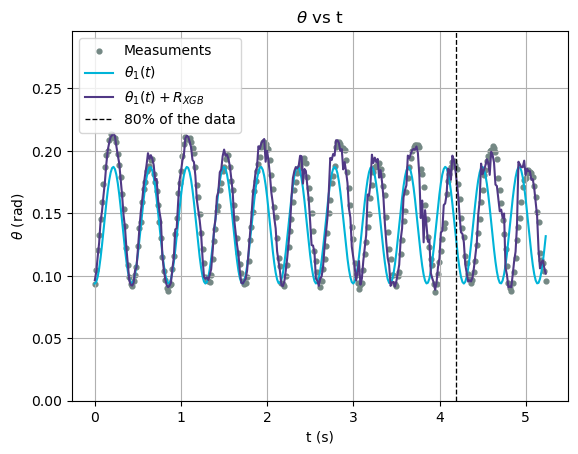

R2: 0.892300591978477


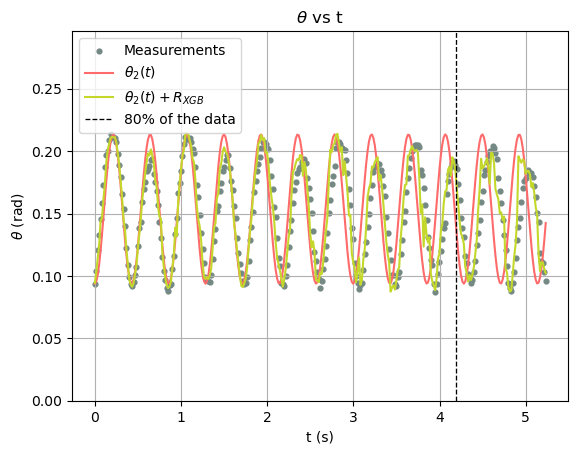

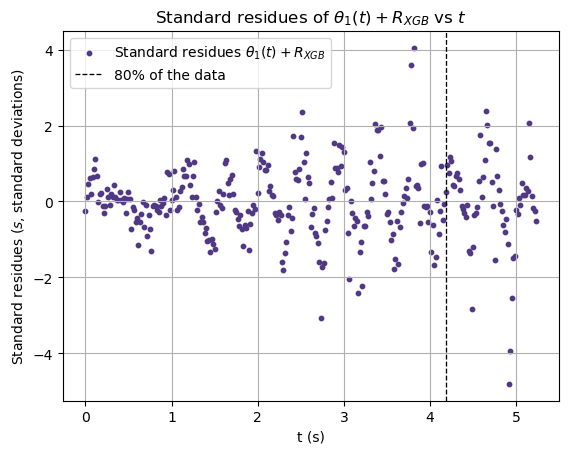

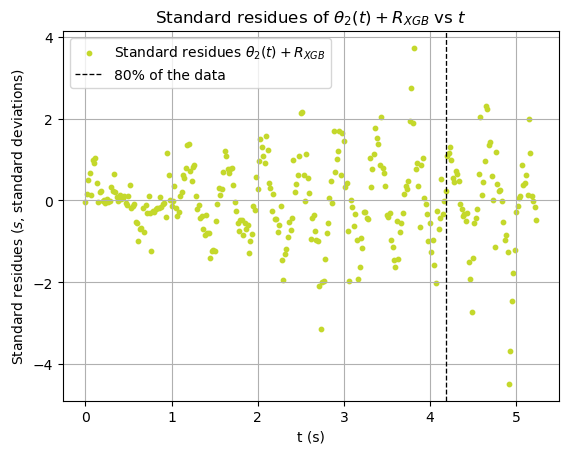

In [26]:
v_XGB_3 = XGBoostTotal(df_3)
r2_3_3 = []
r2_3_3.append(v_XGB_3[0])
r2_3_3.append(v_XGB_3[1])
metrics_3_3 = []
metrics_3_3.append(v_XGB_3[2])
metrics_3_3.append(v_XGB_3[3])
metrics_3_3.append(v_XGB_3[4])
metrics_3_3.append(v_XGB_3[5])

residsXGB(df_3)

R^2 of theta 1: 0.9208924448289594
R^2 of theta 2: 0.892300591978477


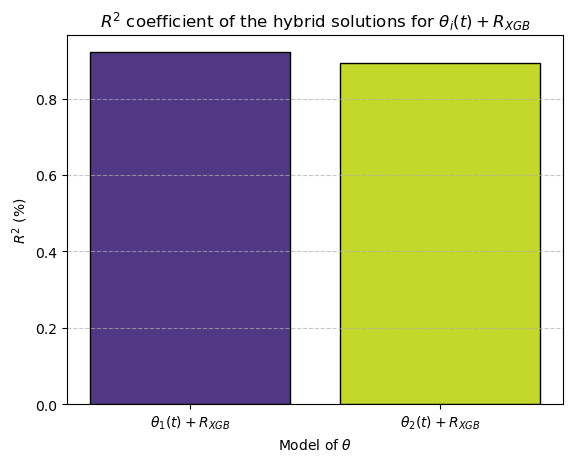

MAPE of the first model: 5.238870306195952
MAPE of the second model: 6.316949029122464
MdAPE of the first model: 3.8441384227690945
MdAPE of the second model: 4.955556425316519


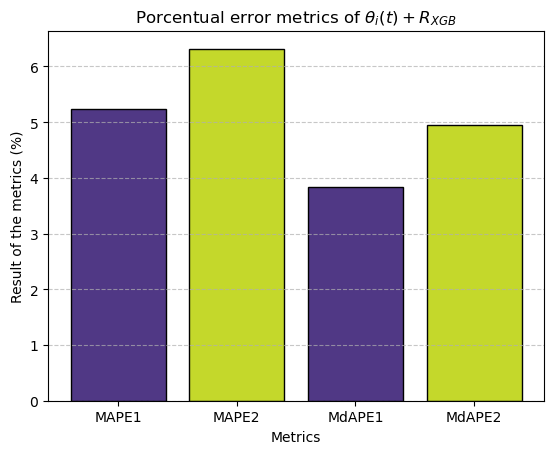

In [27]:
r2_bargraph_XGB(df_3)
errortheta_XGB(df_3)

## **Comparisson between analytical and hybrid solutions**

In [28]:
def bars_metric_1(values, metric):
    values = values.astype(float)
    categories = ["Experiment 1", "Experiment 2", "Experiment 3"]
    subcategories = []
    subcategories = [r"$\theta_1(t)$", r"$\theta_1(t)+R_{RF}$", r"$\theta_1(t)+R_{XGB}$"]
    
    colors = ["#00B4D8", "#503885FF", "#C4D82B"]

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots()
    for i, subcat in enumerate(subcategories):
        bars = ax.bar(x + (i-(len(subcategories)-1)/2)*width, values[:, i], width=width, label=subcat, color=colors[i])

        # For text
        cont = 0
        for bar in bars:
            height = bar.get_height()
            offset = 0.02 * values.max()
            ax.text(bar.get_x() + bar.get_width()/2, height + offset, f'{values[cont, i]}', ha='center', va='bottom', fontsize=7.5)
            cont = cont + 1

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    if metric=="MAPE":
        ax.set_yticks(np.arange(0, 101, 10.1))
        ax.set_ylabel("MAPE (%)")
        ax.set_title(r"MAPE of the models of $\theta_1(t)$")
    elif metric=="MdAPE":
        ax.set_yticks(np.arange(0, 101, 10.1))
        ax.set_ylabel("MdAPE (%)")
        ax.set_title(r"MdAPE of the models of $\theta_1(t)$")
    else:
        ax.set_yticks(np.arange(0, 1.1, 0.10))
        ax.set_ylabel(r"$R^2$")
        ax.set_title(r"$R^2$ of the models of $\theta_1(t)$")

    ax.legend(title="Model", markerscale=0.85, fontsize=8.5)
    
    ax.set_ylim(top=1.46*values.max())
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def bars_metric_2(values, metric):
    values = values.astype(float)
    categories = ["Experiment 1", "Experiment 2", "Experiment 3"]
    subcategories = []
    subcategories = [r"$\theta_2(t)$", r"$\theta_2(t)+R_{RF}$", r"$\theta_2(t)+R_{XGB}$"]
    
    colors = ["#FF6B6B", "#503885FF", "#C4D82B"]

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots()
    for i, subcat in enumerate(subcategories):
        bars = ax.bar(x + (i-(len(subcategories)-1)/2)*width, values[:, i], width=width, label=subcat, color=colors[i])

        # For text
        cont = 0
        for bar in bars:
            height = bar.get_height()
            offset = 0.02 * values.max()
            ax.text(bar.get_x() + bar.get_width()/2, height + offset, f'{values[cont, i]}', ha='center', va='bottom', fontsize=7.5)
            cont = cont + 1

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    if metric=="MAPE":
        ax.set_yticks(np.arange(0, 101, 10.1))
        ax.set_ylabel("MAPE (%)")
        ax.set_title(r"MAPE of the models of $\theta_2(t)$")
    elif metric=="MdAPE":
        ax.set_yticks(np.arange(0, 101, 10.1))
        ax.set_ylabel("MdAPE (%)")
        ax.set_title(r"MdAPE of the models of $\theta_2(t)$")
    else:
        ax.set_yticks(np.arange(0, 1.1, 0.10))
        ax.set_ylabel(r"$R^2$")
        ax.set_title(r"$R^2$ of the models of $\theta_2(t)$")

    ax.legend(title="Model", markerscale=0.85, fontsize=8.5)
    
    ax.set_ylim(top=1.46*values.max())
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### $R^2$

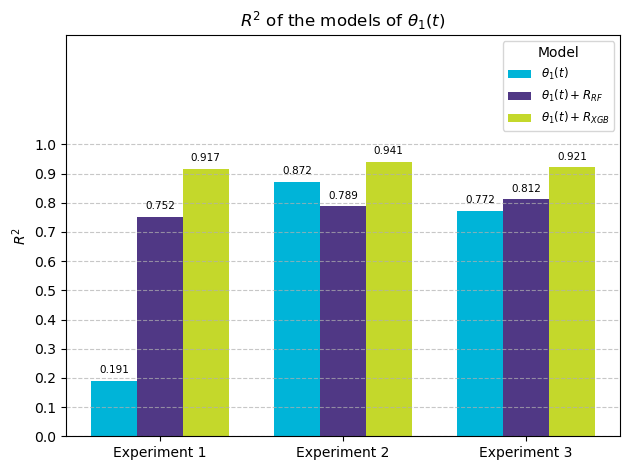

In [29]:
vec_R2_1, vec1_R2_1, vec2_R2_1, vec3_R2_1 = [], [], [], []

vec1_R2_1.append("{:.3g}".format(r2_1_1[0]))
vec1_R2_1.append("{:.3g}".format(r2_2_1[0]))
vec1_R2_1.append("{:.3g}".format(r2_3_1[0]))

vec2_R2_1.append("{:.3g}".format(r2_1_2[0]))
vec2_R2_1.append("{:.3g}".format(r2_2_2[0]))
vec2_R2_1.append("{:.3g}".format(r2_3_2[0]))

vec3_R2_1.append("{:.3g}".format(r2_1_3[0]))
vec3_R2_1.append("{:.3g}".format(r2_2_3[0]))
vec3_R2_1.append("{:.3g}".format(r2_3_3[0]))

vec_R2_1.append(vec1_R2_1)
vec_R2_1.append(vec2_R2_1)
vec_R2_1.append(vec3_R2_1)

vec_R2_1 = np.array(vec_R2_1)

bars_metric_1(vec_R2_1, "R2")

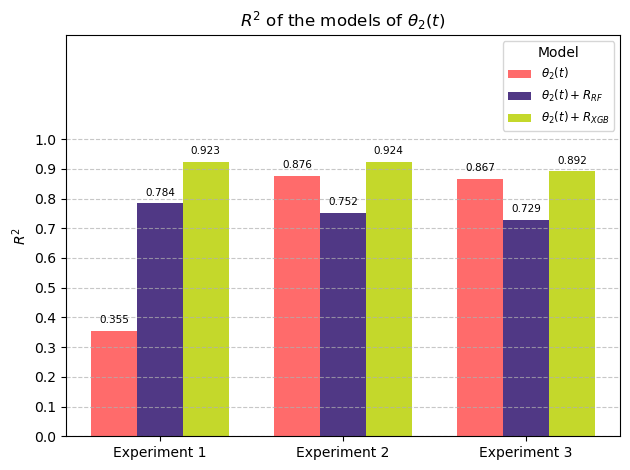

In [30]:
vec_R2_2, vec1_R2_2, vec2_R2_2, vec3_R2_2 = [], [], [], []

vec1_R2_2.append("{:.3g}".format(r2_1_1[1]))
vec1_R2_2.append("{:.3g}".format(r2_2_1[1]))
vec1_R2_2.append("{:.3g}".format(r2_3_1[1]))

vec2_R2_2.append("{:.3g}".format(r2_1_2[1]))
vec2_R2_2.append("{:.3g}".format(r2_2_2[1]))
vec2_R2_2.append("{:.3g}".format(r2_3_2[1]))

vec3_R2_2.append("{:.3g}".format(r2_1_3[1]))
vec3_R2_2.append("{:.3g}".format(r2_2_3[1]))
vec3_R2_2.append("{:.3g}".format(r2_3_3[1]))

vec_R2_2.append(vec1_R2_2)
vec_R2_2.append(vec2_R2_2)
vec_R2_2.append(vec3_R2_2)

vec_R2_2 = np.array(vec_R2_2)

bars_metric_2(vec_R2_2, "R2")

### MAPE

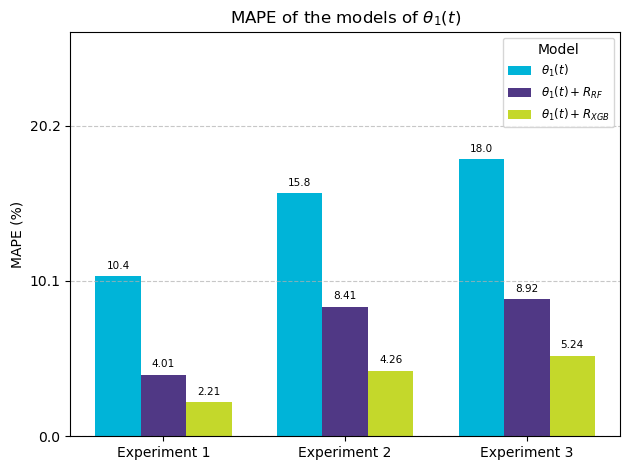

In [31]:
vec_MAPE_1, vec1_MAPE_1, vec2_MAPE_1, vec3_MAPE_1 = [], [], [], []

vec1_MAPE_1.append("{:.3g}".format(metrics_1_1[0]))
vec1_MAPE_1.append("{:.3g}".format(metrics_2_1[0]))
vec1_MAPE_1.append("{:.3g}".format(metrics_3_1[0]))

vec2_MAPE_1.append("{:.3g}".format(metrics_1_2[0]))
vec2_MAPE_1.append("{:.3g}".format(metrics_2_2[0]))
vec2_MAPE_1.append("{:.3g}".format(metrics_3_2[0]))

vec3_MAPE_1.append("{:.3g}".format(metrics_1_3[0]))
vec3_MAPE_1.append("{:.3g}".format(metrics_2_3[0]))
vec3_MAPE_1.append("{:.3g}".format(metrics_3_3[0]))

vec_MAPE_1.append(vec1_MAPE_1)
vec_MAPE_1.append(vec2_MAPE_1)
vec_MAPE_1.append(vec3_MAPE_1)

vec_MAPE_1 = np.array(vec_MAPE_1)

bars_metric_1(vec_MAPE_1, "MAPE")

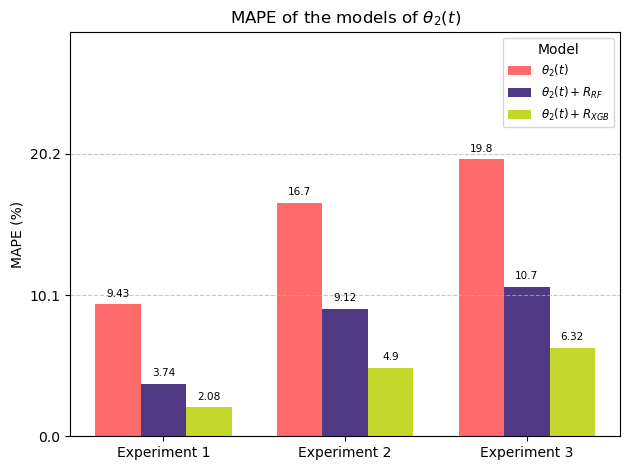

In [32]:
vec_MAPE_2, vec1_MAPE_2, vec2_MAPE_2, vec3_MAPE_2 = [], [], [], []

vec1_MAPE_2.append("{:.3g}".format(metrics_1_1[1]))
vec1_MAPE_2.append("{:.3g}".format(metrics_2_1[1]))
vec1_MAPE_2.append("{:.3g}".format(metrics_3_1[1]))

vec2_MAPE_2.append("{:.3g}".format(metrics_1_2[1]))
vec2_MAPE_2.append("{:.3g}".format(metrics_2_2[1]))
vec2_MAPE_2.append("{:.3g}".format(metrics_3_2[1]))

vec3_MAPE_2.append("{:.3g}".format(metrics_1_3[1]))
vec3_MAPE_2.append("{:.3g}".format(metrics_2_3[1]))
vec3_MAPE_2.append("{:.3g}".format(metrics_3_3[1]))

vec_MAPE_2.append(vec1_MAPE_2)
vec_MAPE_2.append(vec2_MAPE_2)
vec_MAPE_2.append(vec3_MAPE_2)

vec_MAPE_2 = np.array(vec_MAPE_2)

bars_metric_2(vec_MAPE_2, "MAPE")

### MdAPE

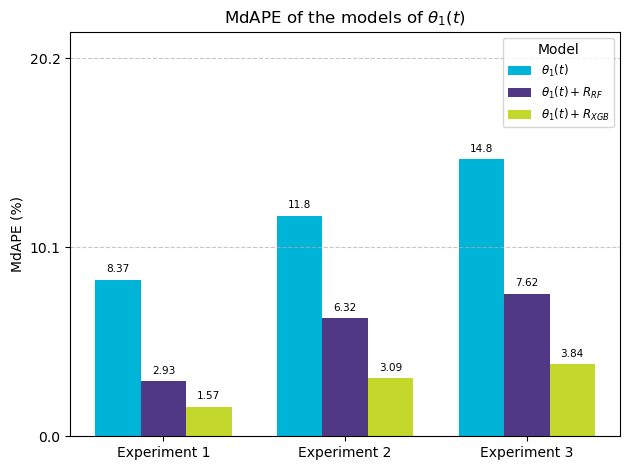

In [35]:
vec_MdAPE_1, vec1_MdAPE_1, vec2_MdAPE_1, vec3_MdAPE_1 = [], [], [], []

vec1_MdAPE_1.append("{:.3g}".format(metrics_1_1[2]))
vec1_MdAPE_1.append("{:.3g}".format(metrics_2_1[2]))
vec1_MdAPE_1.append("{:.3g}".format(metrics_3_1[2]))

vec2_MdAPE_1.append("{:.3g}".format(metrics_1_2[2]))
vec2_MdAPE_1.append("{:.3g}".format(metrics_2_2[2]))
vec2_MdAPE_1.append("{:.3g}".format(metrics_3_2[2]))

vec3_MdAPE_1.append("{:.3g}".format(metrics_1_3[2]))
vec3_MdAPE_1.append("{:.3g}".format(metrics_2_3[2]))
vec3_MdAPE_1.append("{:.3g}".format(metrics_3_3[2]))

vec_MdAPE_1.append(vec1_MdAPE_1)
vec_MdAPE_1.append(vec2_MdAPE_1)
vec_MdAPE_1.append(vec3_MdAPE_1)

vec_MdAPE_1 = np.array(vec_MdAPE_1)

bars_metric_1(vec_MdAPE_1, "MdAPE")

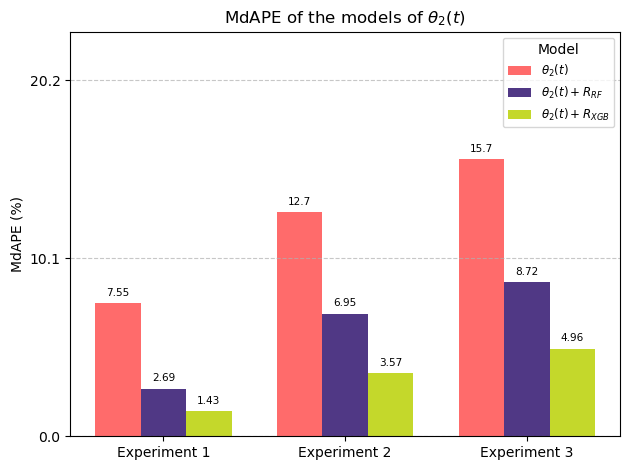

In [34]:
vec_MdAPE_2, vec1_MdAPE_2, vec2_MdAPE_2, vec3_MdAPE_2 = [], [], [], []

vec1_MdAPE_2.append("{:.3g}".format(metrics_1_1[3]))
vec1_MdAPE_2.append("{:.3g}".format(metrics_2_1[3]))
vec1_MdAPE_2.append("{:.3g}".format(metrics_3_1[3]))

vec2_MdAPE_2.append("{:.3g}".format(metrics_1_2[3]))
vec2_MdAPE_2.append("{:.3g}".format(metrics_2_2[3]))
vec2_MdAPE_2.append("{:.3g}".format(metrics_3_2[3]))

vec3_MdAPE_2.append("{:.3g}".format(metrics_1_3[3]))
vec3_MdAPE_2.append("{:.3g}".format(metrics_2_3[3]))
vec3_MdAPE_2.append("{:.3g}".format(metrics_3_3[3]))

vec_MdAPE_2.append(vec1_MdAPE_2)
vec_MdAPE_2.append(vec2_MdAPE_2)
vec_MdAPE_2.append(vec3_MdAPE_2)

vec_MdAPE_2 = np.array(vec_MdAPE_2)

bars_metric_2(vec_MdAPE_2, "MdAPE")